# Does Combine tracking tell you anything the stopwatch and scale don't?
**NFL Big Data Bowl 2027 - measurement audit with defensive-line get-off as the test case.**

Pipeline: (1) load and clean tracking, (2) validate tracking against official times,
(3) audit rep-to-rep reliability of tracking-derived features, (4) test whether tracked burst
predicts DL get-off beyond weight, position and the official forty, (5) test pass-rush drill features,
(6) disclose the abandoned WR route-cut metric, (7) figures.

Decision rules were fixed before looking at outcomes: a feature needs rep-to-rep reliability >= 0.5
to be analysed against game performance. Run top to bottom once.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

R = "/kaggle/input/competitions/nfl-big-data-bowl-2027/nfl-big-data-bowl-2027/"
ct = pd.read_csv(R + "combine_tracking.csv")
cr = pd.read_csv(R + "combine_results.csv")
pp = pd.read_csv(R + "player_play.csv", usecols=[
    "game_id", "nfl_id", "lined_up_position", "player_get_off"])
games = pd.read_csv(R + "games.csv")
ct["t"] = pd.to_datetime(ct.time)
ct = ct.sort_values(["event_id", "t"])
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
BLUE, RED, ORG = "#2e86c1", "#c0392b", "#e67e22"
print(ct.shape, cr.shape, pp.shape, games.shape)

(463189, 15) (510, 18) (314197, 4) (1002, 7)


## 1. Cleaning helpers
Raw tracking has duplicate timestamps and occasional sensor glitches. Each rep is resampled to a uniform
10 Hz grid, lightly smoothed, speed is recomputed from position, and reps with implausible speed are dropped.

In [2]:
def resample_rep(g, smooth, vmax, min_len, min_dur):
    g = g.drop_duplicates("t")
    tt = (g.t - g.t.iloc[0]).dt.total_seconds().values
    if len(tt) < min_len or tt[-1] < min_dur:
        return None
    grid = np.arange(0, tt[-1], 0.1)
    x = pd.Series(np.interp(grid, tt, g.x.values)).rolling(smooth, center=True, min_periods=1).mean().values
    y = pd.Series(np.interp(grid, tt, g.y.values)).rolling(smooth, center=True, min_periods=1).mean().values
    vx, vy = np.gradient(x, 0.1), np.gradient(y, 0.1)
    s = np.hypot(vx, vy)
    if s.max() > vmax:
        return None
    return x, y, s, np.unwrap(np.arctan2(vy, vx))


def two_rep_reliability(df, key, feats, order):
    """Rep-to-rep correlation, stepped up to a 2-rep-mean reliability (Spearman-Brown)."""
    df = df.sort_values([key, order]).copy()
    df["k"] = df.groupby(key).cumcount()
    w = df[df.k < 2].pivot(index=key, columns="k", values=feats).dropna()
    out = {}
    for f in feats:
        r = w[(f, 0)].corr(w[(f, 1)])
        out[f] = 2 * r / (1 + r)
    return out, len(w)

## 2. 40-yard dash: features, validity, reliability
Only 15 of 793 reps reach 40 yards in the tracking data, so tracked 40-yard time is not usable.
Speed-profile features (speed at 1 s and 2 s, peak speed, peak acceleration, time to 20 yards) are.

In [3]:
def dash_feats(rep):
    x, y, s, _ = rep
    mv = np.where(s > 1.0)[0]
    if len(mv) == 0:
        return None
    i0 = mv[0]
    if i0 + 25 >= len(s):
        return None
    d = np.concatenate([[0], np.cumsum(np.hypot(np.diff(x), np.diff(y)))])
    d -= d[i0]
    def t_at(yd):
        j = np.where(d >= yd)[0]
        return (j[0] - i0) * 0.1 if len(j) else np.nan
    a = np.gradient(s, 0.1)
    return dict(t10=t_at(10), t20=t_at(20), peak_speed=s.max(),
                v_1s=s[i0 + 10], v_2s=s[i0 + 20], peak_accel=a[i0:i0 + 30].max())

fd = ct[ct.drill_name == "FORTY_YARD_DASH"]
rows = []
for (pid, ev, att), g in fd.groupby(["nfl_id", "event_id", "attempt"]):
    rep = resample_rep(g, smooth=3, vmax=13, min_len=40, min_dur=3.5)
    f = dash_feats(rep) if rep else None
    if f:
        rows.append(dict(nfl_id=pid, event_id=ev, attempt=att, **f))
dash = pd.DataFrame(rows).dropna(subset=["t10"])
print("usable dash reps:", len(dash), "| players:", dash.nfl_id.nunique())

DF = ["t10", "t20", "peak_speed", "v_1s", "v_2s", "peak_accel"]
pm = (dash.groupby("nfl_id")[DF].mean().reset_index().merge(cr, on="nfl_id"))
print("validity vs official times (player means):")
print(pm[["peak_speed", "v_2s", "t20", "v_1s", "t10", "forty", "ten_yd_split"]]
      .corr()[["forty", "ten_yd_split"]].round(2))

rel_dash, n_dash = two_rep_reliability(dash, "nfl_id", DF, "event_id")
print(f"\nreliability of 2-rep mean (n={n_dash} players with 2 reps):",
      {k: round(v, 2) for k, v in rel_dash.items()})

usable dash reps: 793 | players: 418
validity vs official times (player means):
              forty  ten_yd_split
peak_speed    -0.98         -0.93
v_2s          -0.86         -0.82
t20            0.72          0.68
v_1s          -0.53         -0.52
t10            0.46          0.43
forty          1.00          0.95
ten_yd_split   0.95          1.00

reliability of 2-rep mean (n=375 players with 2 reps): {'t10': np.float64(0.37), 't20': np.float64(0.61), 'peak_speed': np.float64(0.99), 'v_1s': np.float64(0.58), 'v_2s': np.float64(0.78), 'peak_accel': np.float64(0.56)}


## 3. Outcome test: does tracked burst predict DL get-off beyond weight, position and the forty?
The primary feature (speed at 2 s) and the controls were fixed in advance.

In [4]:
pp = pp.merge(games[["game_id", "season_type"]], on="game_id", how="left")
print("plays by season type:\n", pp.season_type.value_counts(dropna=False))
g = pp[(pp.season_type == "REG")
       & pp.lined_up_position.isin(["EDGE", "INTERIOR_LINE"]) & pp.player_get_off.notna()]
print("regular-season get-off plays kept:", len(g))
print("player_get_off summary:\n", g.player_get_off.describe().round(2))
pl = (g.groupby("nfl_id")
        .agg(get_off=("player_get_off", "mean"), n=("player_get_off", "size"),
             edge_share=("lined_up_position", lambda s: (s == "EDGE").mean()))
        .query("n >= 30").reset_index())
d = pm.merge(pl, on="nfl_id")
d = d[d.combine_position == "DL"].dropna(subset=["v_2s", "forty", "combine_weight"]).copy()
d["grp"] = np.where(d.edge_share > 0.5, "EDGE", "INTERIOR")
print("\nDL with dash features and >=30 get-off plays:", len(d), d.grp.value_counts().to_dict())

m_base = smf.ols("get_off ~ combine_weight + C(grp)", data=d).fit()
m_stop = smf.ols("get_off ~ combine_weight + C(grp) + forty", data=d).fit()
m_trk = smf.ols("get_off ~ combine_weight + C(grp) + v_2s", data=d).fit()
m_both = smf.ols("get_off ~ combine_weight + C(grp) + forty + v_2s", data=d).fit()
for k, m in {"weight+group": m_base, "+ official forty": m_stop,
             "+ tracked v_2s": m_trk, "+ both": m_both}.items():
    print(f"{k:18s} adj R2 {m.rsquared_adj:.3f}")
print("\nDoes v_2s add beyond forty?\n", anova_lm(m_stop, m_both).round(3))
print(m_both.summary().tables[1])
d["resid"] = m_base.resid
print("\nweight vs get-off r:", round(d.combine_weight.corr(d.get_off), 2))

plays by season type:
 season_type
REG     249269
PRE      51759
POST     13169
Name: count, dtype: int64
regular-season get-off plays kept: 33577
player_get_off summary:
 count    33577.00
mean         1.01
std          0.29
min          0.00
25%          0.81
50%          0.96
75%          1.16
max          2.00
Name: player_get_off, dtype: float64

DL with dash features and >=30 get-off plays: 68 {'INTERIOR': 37, 'EDGE': 31}
weight+group       adj R2 0.464
+ official forty   adj R2 0.482
+ tracked v_2s     adj R2 0.480
+ both             adj R2 0.476

Does v_2s add beyond forty?
    df_resid    ssr  df_diff  ss_diff      F  Pr(>F)
0      64.0  0.344      0.0      NaN    NaN     NaN
1      63.0  0.342      1.0    0.001  0.268   0.606
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.4408      0.849      0.519      0.605      -1.256      

## 4. Pass-rush drill: reliable features, linked to weight-adjusted get-off
Six features tested, so any single association would be a hypothesis, not a finding.

In [5]:
def passrush_feats(rep):
    x, y, s, _ = rep
    a = np.gradient(s, 0.1)
    mv = s > 1.0
    return dict(dur=mv.sum() * 0.1, path=np.hypot(np.diff(x), np.diff(y)).sum(),
                peak_speed=s.max(), mean_speed=s[mv].mean() if mv.any() else np.nan,
                peak_accel=a.max(), peak_decel=-a.min())

dl = ct[(ct.drill_type == "SKILL_DRILLS_DL") & (ct.drill_name == "PASS_RUSH_DRILL")]
rows = []
for (pid, ev), g in dl.groupby(["nfl_id", "event_id"]):
    rep = resample_rep(g, smooth=5, vmax=12, min_len=20, min_dur=1.5)
    if rep:
        rows.append(dict(nfl_id=pid, event_id=ev, **passrush_feats(rep)))
pr = pd.DataFrame(rows)
PF = ["dur", "path", "peak_speed", "mean_speed", "peak_accel", "peak_decel"]
rel_pr, n_pr = two_rep_reliability(pr, "nfl_id", PF, "event_id")
print(f"usable reps: {len(pr)} | players with 2 reps: {n_pr}")
print({k: round(v, 2) for k, v in rel_pr.items()})

j = d[["nfl_id", "resid"]].merge(pr.groupby("nfl_id")[PF].mean().reset_index(), on="nfl_id")
print("\nDL linked to pass-rush drill and get-off:", len(j))
print(j[PF + ["resid"]].corr().resid.round(2))

usable reps: 217 | players with 2 reps: 102
{'dur': np.float64(0.3), 'path': np.float64(0.1), 'peak_speed': np.float64(0.75), 'mean_speed': np.float64(0.54), 'peak_accel': np.float64(0.69), 'peak_decel': np.float64(0.79)}

DL linked to pass-rush drill and get-off: 65
dur          -0.02
path         -0.03
peak_speed   -0.02
mean_speed   -0.00
peak_accel    0.02
peak_decel    0.01
resid         1.00
Name: resid, dtype: float64


## 5. Disclosed dead end: WR route-cut "sharpness" metric
Built to predict separation at pass forward. Rep-to-rep reliability is near zero, so it is abandoned
before any outcome analysis. Slant routes were excluded in advance: cut detection fails on gentle breaks.

In [6]:
def cut_feats(rep, h=5, thr=35):
    x, y, s, head = rep
    n = len(s)
    turn = np.zeros(n)
    for i in range(h + 8, n - h):
        if s[i - h - 3: i - h + 1].mean() > 3.0 and s[i] > 1.0 and s[i + h] > 1.0:
            turn[i] = abs(np.degrees(head[i + h] - head[i - h]))
    idx = np.where(turn >= thr)[0]
    if len(idx) == 0:
        return None
    a = idx[0] + int(np.argmax(turn[idx[0]: idx[0] + 8]))
    sin = s[a - 8: a - 3].mean()
    if sin < 3.0 or a + 12 > n:
        return None
    post = s[a + 3: a + 13]
    arc = np.hypot(np.diff(x), np.diff(y))[a - h: a + h].sum()
    return dict(retention=s[a: a + 9].min() / sin, exit_ratio=post.max() / sin,
                radius=arc / np.radians(turn[a]))

wr = ct[ct.drill_type == "SKILL_DRILLS_WR"].copy()
wr["drill"] = (wr.drill_name.str.replace("_ROUTE", "", regex=False)
                            .str.replace(r"_(LEFT|RIGHT)$", "", regex=True))
BREAK = ["DAGGER", "SPEED_OUT", "COMEBACK", "CURL", "POST_CORNER", "SLOT_SAIL"]
rows = []
for (pid, ev, dn), g in wr[wr.drill.isin(BREAK)].groupby(["nfl_id", "event_id", "drill"]):
    rep = resample_rep(g, smooth=5, vmax=12, min_len=30, min_dur=2.0)
    f = cut_feats(rep) if rep else None
    if f:
        rows.append(dict(nfl_id=pid, event_id=ev, drill=dn, **f))
bf = pd.DataFrame(rows)
for c in ["retention", "exit_ratio", "radius"]:
    lo, hi = bf[c].quantile([.01, .99])
    bf[c] = bf[c].clip(lo, hi)
    bf[c + "_z"] = bf.groupby("drill")[c].transform(lambda s: (s - s.mean()) / s.std())
bf["sharp"] = bf.retention_z + bf.exit_ratio_z - bf.radius_z
keep = bf.groupby("nfl_id").size()
b = bf[bf.nfl_id.isin(keep[keep >= 3].index)]
rs = []
for seed in range(200):
    bb = b.sample(frac=1, random_state=seed).copy()
    bb["half"] = bb.groupby("nfl_id").cumcount() % 2
    m = bb.pivot_table(index="nfl_id", columns="half", values="sharp", aggfunc="mean").dropna()
    r = m[0].corr(m[1])
    rs.append(2 * r / (1 + r))
rel_wr = float(np.mean(rs))
print(f"WR cut-sharpness split-half reliability: {rel_wr:.2f} (players: {b.nfl_id.nunique()})")

WR cut-sharpness split-half reliability: 0.14 (players: 106)


## 6. Figures

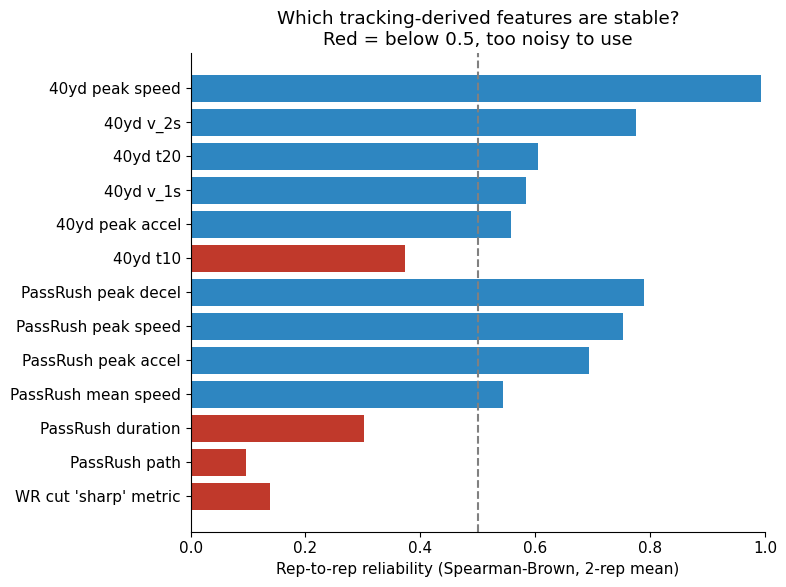

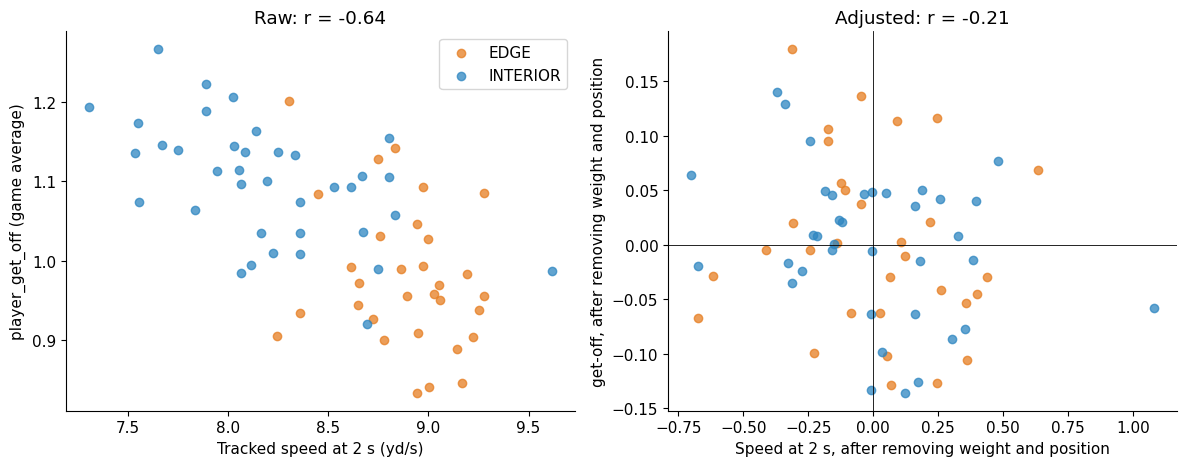

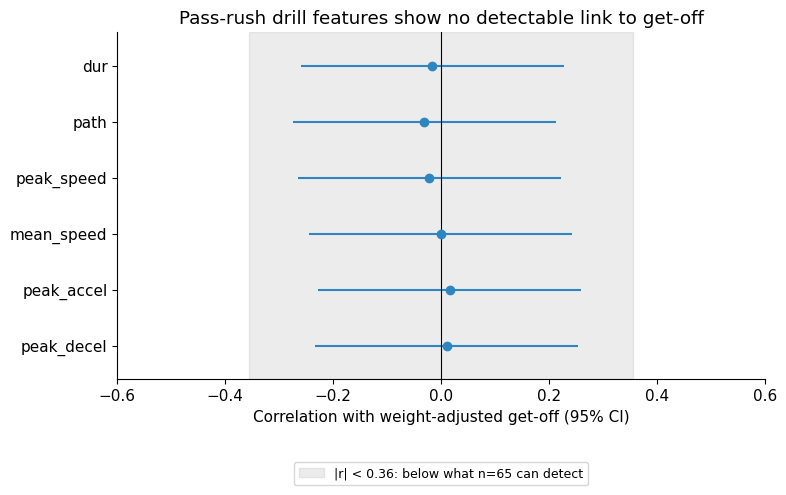

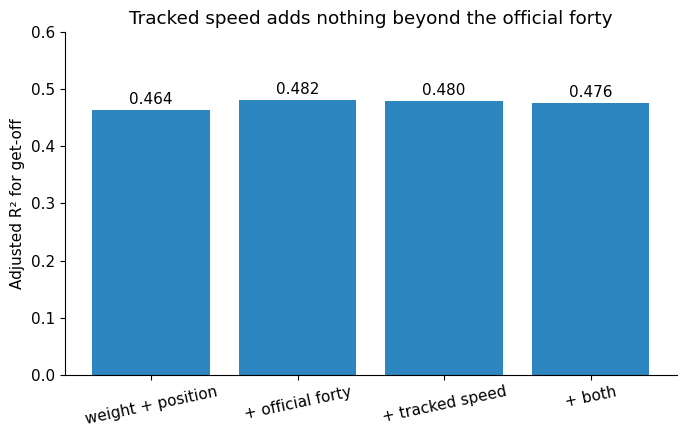

minimum detectable |r|: 0.36 | raw r: -0.64 | adjusted r: -0.21


In [7]:
OUT = "/kaggle/working/"
rel = {"40yd peak speed": rel_dash["peak_speed"], "40yd v_2s": rel_dash["v_2s"],
       "40yd t20": rel_dash["t20"], "40yd v_1s": rel_dash["v_1s"],
       "40yd peak accel": rel_dash["peak_accel"], "40yd t10": rel_dash["t10"],
       "PassRush peak decel": rel_pr["peak_decel"], "PassRush peak speed": rel_pr["peak_speed"],
       "PassRush peak accel": rel_pr["peak_accel"], "PassRush mean speed": rel_pr["mean_speed"],
       "PassRush duration": rel_pr["dur"], "PassRush path": rel_pr["path"],
       "WR cut 'sharp' metric": rel_wr}

# Figure 1: reliability audit
k = list(rel)[::-1]; v = [rel[i] for i in k]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(k, v, color=[RED if x < .5 else BLUE for x in v])
ax.axvline(.5, ls="--", c="gray"); ax.set_xlim(0, 1)
ax.set_xlabel("Rep-to-rep reliability (Spearman-Brown, 2-rep mean)")
ax.set_title("Which tracking-derived features are stable?\nRed = below 0.5, too noisy to use")
plt.tight_layout(); plt.savefig(OUT + "fig1_reliability.png", dpi=200); plt.show()

# Figure 2: raw vs weight-adjusted
v_res = smf.ols("v_2s ~ combine_weight + C(grp)", data=d).fit().resid
r_raw = d.v_2s.corr(d.get_off); r_adj = v_res.corr(d.resid)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
for g_, c in [("EDGE", ORG), ("INTERIOR", BLUE)]:
    m = d.grp == g_
    ax[0].scatter(d.v_2s[m], d.get_off[m], c=c, label=g_, alpha=.75)
    ax[1].scatter(v_res[m], d.resid[m], c=c, alpha=.75)
ax[0].set_xlabel("Tracked speed at 2 s (yd/s)"); ax[0].set_ylabel("player_get_off (game average)")
ax[0].set_title(f"Raw: r = {r_raw:.2f}"); ax[0].legend()
ax[1].axhline(0, c="k", lw=.6); ax[1].axvline(0, c="k", lw=.6)
ax[1].set_xlabel("Speed at 2 s, after removing weight and position")
ax[1].set_ylabel("get-off, after removing weight and position")
ax[1].set_title(f"Adjusted: r = {r_adj:.2f}")
plt.tight_layout(); plt.savefig(OUT + "fig2_raw_vs_adjusted.png", dpi=200); plt.show()

# Figure 4 (computed first): effect sizes with CIs vs minimum detectable effect
n = len(j); mde = 2.8 / np.sqrt(n - 3); rows3 = []
for f in PF:
    r = j[f].corr(j["resid"]); z = np.arctanh(r); se = 1 / np.sqrt(n - 3)
    rows3.append((f, r, np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)))
rows3 = rows3[::-1]
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.axvspan(-mde, mde, color="gray", alpha=.15, label=f"|r| < {mde:.2f}: below what n={n} can detect")
ax.errorbar([r[1] for r in rows3], range(len(rows3)),
            xerr=[[r[1] - r[2] for r in rows3], [r[3] - r[1] for r in rows3]], fmt="o", c=BLUE)
ax.axvline(0, c="k", lw=.8); ax.set_xlim(-.6, .6)
ax.set_yticks(range(len(rows3))); ax.set_yticklabels([r[0] for r in rows3])
ax.set_xlabel("Correlation with weight-adjusted get-off (95% CI)")
ax.set_title("Pass-rush drill features show no detectable link to get-off")
ax.set_ylim(-0.6, len(rows3) - 0.4)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), fontsize=9)
plt.tight_layout(); plt.savefig(OUT + "fig4_effect_sizes.png", dpi=200, bbox_inches="tight"); plt.show()

# Figure 3: model comparison
names = ["weight + position", "+ official forty", "+ tracked speed", "+ both"]
vals = [m_base.rsquared_adj, m_stop.rsquared_adj, m_trk.rsquared_adj, m_both.rsquared_adj]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(names, vals, color=BLUE); ax.set_ylim(0, .6)
for i, x in enumerate(vals):
    ax.text(i, x + .01, f"{x:.3f}", ha="center")
ax.set_ylabel("Adjusted R² for get-off")
ax.set_title("Tracked speed adds nothing beyond the official forty")
plt.setp(ax.get_xticklabels(), rotation=12)
plt.tight_layout(); plt.savefig(OUT + "fig3_models.png", dpi=200); plt.show()
print(f"minimum detectable |r|: {mde:.2f} | raw r: {r_raw:.2f} | adjusted r: {r_adj:.2f}")

In [8]:
import scipy.stats as st

print("usable dash reps:", len(dash), "| players:", dash.nfl_id.nunique())

r = v_res.corr(d.resid); n_ = len(d); k_ = 2
z = np.arctanh(r); se = 1 / np.sqrt(n_ - 3 - k_)
lo, hi = np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)
t = r * np.sqrt((n_ - 2 - k_) / (1 - r**2)); p = 2 * st.t.sf(abs(t), n_ - 2 - k_)
print(f"\nadjusted r = {r:.2f}, 95% CI [{lo:.2f}, {hi:.2f}], p = {p:.3f}, n = {n_}")

m_w = smf.ols("get_off ~ combine_weight", data=d).fit()
for name, m in {"weight only": m_w, "weight + group": m_base, "full (+ forty + v_2s)": m_both}.items():
    print(f"{name:22s} per 10 lb: {10*m.params['combine_weight']:.3f} s, p = {m.pvalues['combine_weight']:.3g}")
g_ = "C(grp)[T.INTERIOR]"
print(f"interior vs edge: base p = {m_base.pvalues[g_]:.2f}, full p = {m_both.pvalues[g_]:.2f}")
print("weight vs get-off r:", round(d.combine_weight.corr(d.get_off), 2))
print("n DL:", len(d), d.grp.value_counts().to_dict(), "| pass-rush linked n:", len(j))

usable dash reps: 793 | players: 418

adjusted r = -0.21, 95% CI [-0.43, 0.03], p = 0.088, n = 68
weight only            per 10 lb: 0.024 s, p = 6.29e-11
weight + group         per 10 lb: 0.022 s, p = 0.00014
full (+ forty + v_2s)  per 10 lb: 0.014 s, p = 0.065
interior vs edge: base p = 0.76, full p = 0.89
weight vs get-off r: 0.69
n DL: 68 {'INTERIOR': 37, 'EDGE': 31} | pass-rush linked n: 65


In [9]:
print("season types:", pp.season_type.value_counts(dropna=False).to_dict())
print("REG get-off plays kept:",
      int(((pp.season_type == "REG") & pp.lined_up_position.isin(["EDGE", "INTERIOR_LINE"])
           & pp.player_get_off.notna()).sum()))
for k, m in {"weight+group": m_base, "+ official forty": m_stop,
             "+ tracked v_2s": m_trk, "+ both": m_both}.items():
    print(f"{k:18s} adj R2 {m.rsquared_adj:.3f}")
print("F-test, v_2s beyond forty: p =", round(float(anova_lm(m_stop, m_both)['Pr(>F)'].iloc[1]), 3))
print("v_2s coef in full model:", round(m_both.params['v_2s'], 4), "| p =", round(m_both.pvalues['v_2s'], 3))
print("raw r, tracked speed vs get-off:", round(d.v_2s.corr(d.get_off), 2))
print("min detectable |r| (pass-rush, n=%d): %.2f" % (len(j), 2.8 / np.sqrt(len(j) - 3)))
print(j[PF + ["resid"]].corr().resid.round(2))

season types: {'REG': 249269, 'PRE': 51759, 'POST': 13169}
REG get-off plays kept: 33577
weight+group       adj R2 0.464
+ official forty   adj R2 0.482
+ tracked v_2s     adj R2 0.480
+ both             adj R2 0.476
F-test, v_2s beyond forty: p = 0.606
v_2s coef in full model: -0.023 | p = 0.606
raw r, tracked speed vs get-off: -0.64
min detectable |r| (pass-rush, n=65): 0.36
dur          -0.02
path         -0.03
peak_speed   -0.02
mean_speed   -0.00
peak_accel    0.02
peak_decel    0.01
resid         1.00
Name: resid, dtype: float64
